# **TinyML-Human Activitiy Recognition System**

In [ ]:
!pip install -q tensorflow
!pip install -q scikit-learn matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
print("Tensorflow version: ", tf.__version__)
print("All libraries imported successfully")

Tensorflow version:  2.19.0
All libraries imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuration
ACTIVITIES = ['idle', 'walking', 'running', 'jumping']
WINDOW_SIZE = 80                           # Number of samples per window
STEP_SIZE = 40                              # Sliding window step (50% overlap)

# Path to your data in Google Drive
# IMPORTANT: Update this path if your folder structure is different
DATA_PATH = '/content/drive/MyDrive/HAR_Project/sensor_data'

print(f"Data path: {DATA_PATH}")
print(f"Activities: {ACTIVITIES}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Step size: {STEP_SIZE}")

Data path: /content/drive/MyDrive/HAR_Project/sensor_data
Activities: ['idle', 'walking', 'running', 'jumping']
Window size: 80
Step size: 40


In [ ]:
#Data Loading Functions
def load_csv_file(file_path):
    """
    Load sensor data from a single CSV file
    Handles different phyphox export formats
    """
    try:
        df = pd.read_csv(file_path)

        # Try different possible column name formats from phyphox
        possible_formats = [
            ['Acceleration x (m/s^2)', 'Acceleration y (m/s^2)', 'Acceleration z (m/s^2)'],
            ['Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)'],
            ['ax', 'ay', 'az'],
            ['Acc_x', 'Acc_y', 'Acc_z']
        ]

        # Try each format
        for format_cols in possible_formats:
            if all(col in df.columns for col in format_cols):
                data = df[format_cols].values
                return data

        # If no standard format found, use first 3 numeric columns after time
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) >= 3:
            # Usually first column is time, so skip it
            data = df[numeric_cols[1:4]].values
            return data
        else:
            print(f"Warning: Could not find acceleration columns in {file_path}")
            return None

    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def create_windows(data, window_size, step_size):
    """
    Create sliding windows from continuous sensor data
    """
    windows = []
    num_samples = len(data)

    for start_idx in range(0, num_samples - window_size + 1, step_size):
        window = data[start_idx:start_idx + window_size]
        if len(window) == window_size:
            windows.append(window)

    return np.array(windows)

def load_activity_data(activity_path, activity_label):
    """
    Load all CSV files for a specific activity
    """
    windows = []
    labels = []

    csv_files = sorted([f for f in os.listdir(activity_path) if f.endswith('.csv')])

    print(f" Found {len(csv_files)} CSV files")

    files_processed = 0
    total_windows = 0

    for csv_file in csv_files:
        file_path = os.path.join(activity_path, csv_file)
        data = load_csv_file(file_path)

        if data is not None and len(data) >= WINDOW_SIZE:
            # Create windows from this file
            file_windows = create_windows(data, WINDOW_SIZE, STEP_SIZE)

            if len(file_windows) > 0:
                windows.extend(file_windows)
                labels.extend([activity_label] * len(file_windows))
                total_windows += len(file_windows)
                files_processed += 1

    print(f" Processed {files_processed} files → {total_windows} windows")

    return np.array(windows), np.array(labels)

print("✓ Data loading functions defined")



✓ Data loading functions defined


In [ ]:
#Load All Data
print("=" * 60)
print("LOADING DATA FROM GOOGLE DRIVE")
print("=" * 60)

# Check if data path exists
if not os.path.exists(DATA_PATH):
    print(f"\n❌ ERROR: Data path not found!")
    print(f"Looking for: {DATA_PATH}")
    print("\nPlease ensure:")
    print("1. You've uploaded 'sensor_data' folder to Google Drive")
    print("2. The path in DATA_PATH variable is correct")
    print("3. Google Drive is properly mounted")
else:
    print(f"✓ Data path found: {DATA_PATH}\n")

all_windows = []
all_labels = []

for activity_idx, activity_name in enumerate(ACTIVITIES):
    activity_path = os.path.join(DATA_PATH, activity_name)

    print(f"\n[{activity_idx + 1}/{len(ACTIVITIES)}] Loading {activity_name.upper()}:")

    if not os.path.exists(activity_path):
        print(f" ❌ ERROR: Folder not found - {activity_path}")
        continue

    windows, labels = load_activity_data(activity_path, activity_idx)

    all_windows.append(windows)
    all_labels.append(labels)

# Combine all data
X = np.vstack(all_windows)
y = np.concatenate(all_labels)

print("\n" + "=" * 60)
print("DATA LOADING COMPLETE")
print("=" * 60)
print(f"\n✓ Total windows: {len(X)}")
print(f"✓ Data shape: {X.shape}")
print(f"✓ Labels shape: {y.shape}")

# Display class distribution
print("\n📊 Class Distribution:")
for idx, activity in enumerate(ACTIVITIES):
    count = np.sum(y == idx)
    percentage = (count / len(y)) * 100
    print(f" {activity:10s}: {count:5d} windows ({percentage:5.1f}%)")

# Visualize sample data
print("\n📈 Sample sensor data (first window of idle):")
sample_window = X[0]
print(f"Shape: {sample_window.shape}")
print(f"First 5 timesteps:\n{sample_window[:5]}")

LOADING DATA FROM GOOGLE DRIVE


NameError: name 'os' is not defined

✓ Sample visualization saved!


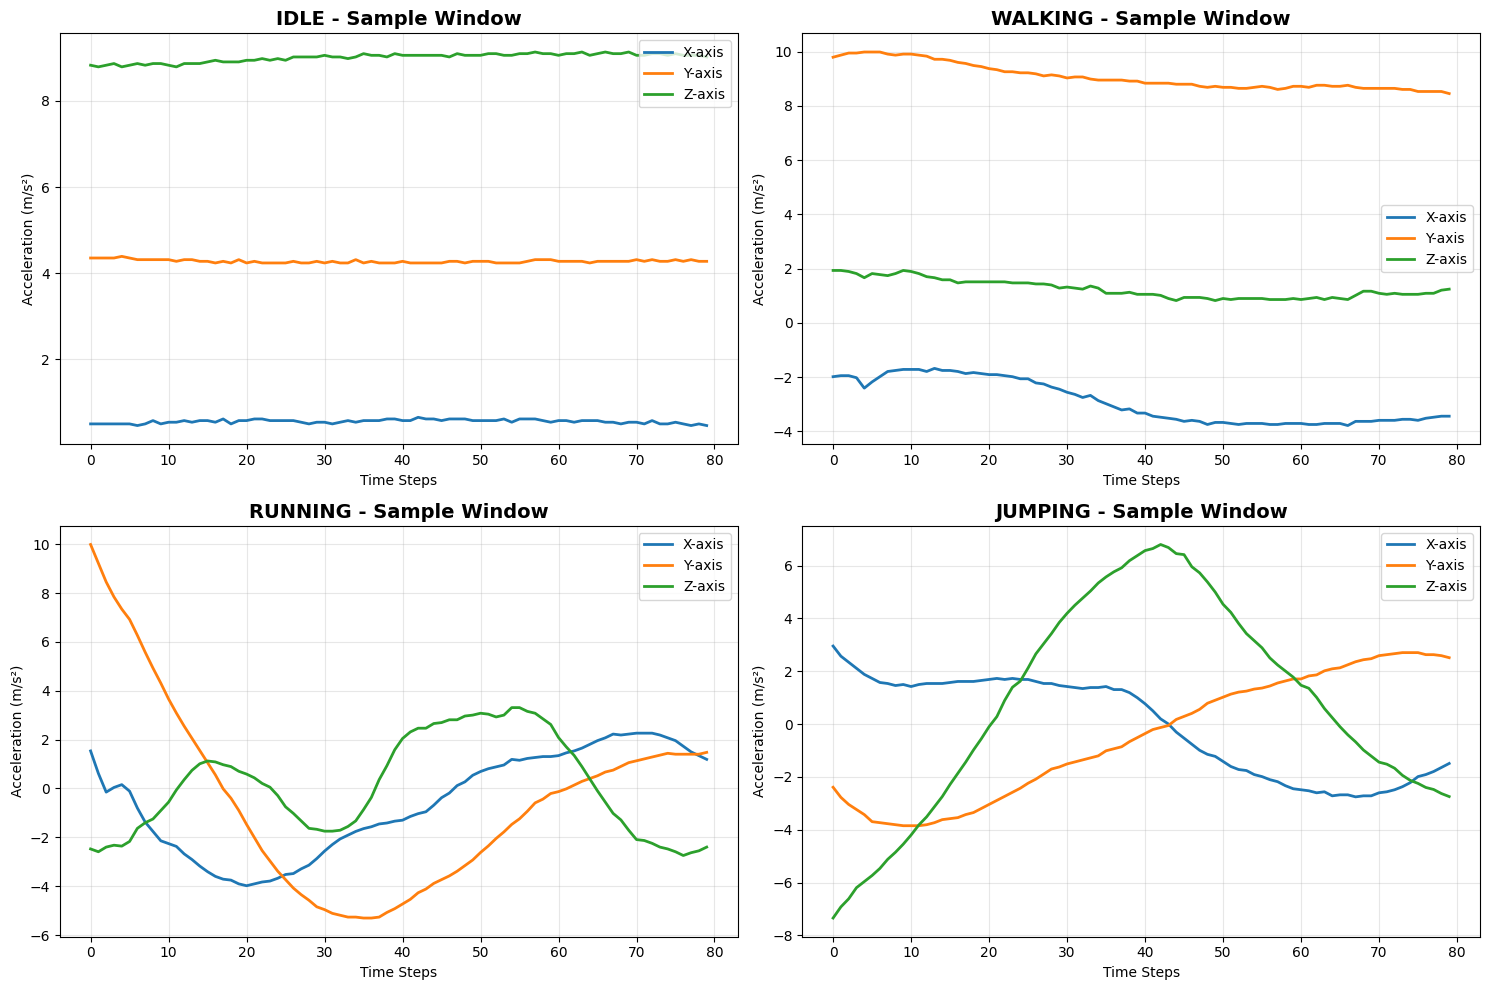

In [ ]:
# Visualize Sample Data
# Visualize sample windows from each activity
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, activity in enumerate(ACTIVITIES):
    # Get first window of this activity
    activity_indices = np.where(y == idx)[0]
    if len(activity_indices) > 0:
        sample = X[activity_indices[0]]

        ax = axes[idx]
        ax.plot(sample[:, 0], label='X-axis', linewidth=2)
        ax.plot(sample[:, 1], label='Y-axis', linewidth=2)
        ax.plot(sample[:, 2], label='Z-axis', linewidth=2)
        ax.set_title(f'{activity.upper()} - Sample Window', fontsize=14, fontweight='bold')
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Acceleration (m/s²)')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HAR_Project/sample_data_visualization.png', dpi=300, bbox_inches='tight')
print("✓ Sample visualization saved!")
plt.show()

In [ ]:
#Split Data
print("=" * 60)
print("SPLITTING DATA")
print("=" * 60)

# Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n✓ Training set: {len(X_train):5d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"✓ Validation set: {len(X_val):5d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"✓ Test set: {len(X_test):5d} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nInput shape per sample: {X_train[0].shape}")

SPLITTING DATA

✓ Training set: 15185 samples (70.0%)
✓ Validation set:  3254 samples (15.0%)
✓ Test set:  3255 samples (15.0%)

Input shape per sample: (80, 3)


In [ ]:
#CELL 8: Build Model
def build_cnn_model(input_shape, num_classes):
    """
    Build a CNN model optimized for TinyML deployment
    Small model size suitable for microcontrollers
    """
    model = keras.Sequential([
        # First Conv block
        keras.layers.Conv1D(16, kernel_size=3, activation='relu',
                           input_shape=input_shape, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Dropout(0.2),

        # Second Conv block
        keras.layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Dropout(0.3),

        # Dense layers
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Build model
print("=" * 60)
print("BUILDING MODEL")
print("=" * 60)

input_shape = (X_train.shape[1], X_train.shape[2]) # (80, 3)
num_classes = len(ACTIVITIES)

model = build_cnn_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📋 Model Architecture:")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n✓ Total parameters: {total_params:,}")

BUILDING MODEL

📋 Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 80, 16)         │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 40, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,204 (168.77 KB)

 Trainable params: 43,108 (168.39 KB)

 Non-trainable params: 96 (384.00 B)


✓ Total parameters: 43,204


In [ ]:
#Train Model
print("\n" + "=" * 60)
print("TRAINING MODEL")
print("=" * 60)
print("This will take 3-5 minutes...\n")

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✓ Training complete!")


TRAINING MODEL
This will take 3-5 minutes...

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8494 - loss: 0.4751 - val_accuracy: 0.9757 - val_loss: 0.0871 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9623 - loss: 0.1129 - val_accuracy: 0.9908 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9736 - loss: 0.0813 - val_accuracy: 0.9874 - val_loss: 0.0398 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9792 - loss: 0.0606 - val_accuracy: 0.9923 - val_loss: 0.0285 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9822 - loss: 0.0536 - val_accuracy: 0.9932 - val_loss: 0.0248 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9831 - loss: 0.0506 - val_accuracy: 0.9942 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━

In [ ]:
#Evaluate Model
print("=" * 60)
print("EVALUATING MODEL")
print("=" * 60)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\n📊 Test Results:")
print(f" Accuracy: {test_acc * 100:.2f}%")
print(f" Loss: {test_loss:.4f}")

# Predictions
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

# Classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=ACTIVITIES))


EVALUATING MODEL

📊 Test Results:
 Accuracy: 99.78%
 Loss: 0.0099

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       789
     walking       1.00      1.00      1.00       855
     running       1.00      0.99      1.00       854
     jumping       1.00      1.00      1.00       757

    accuracy                           1.00      3255
   macro avg       1.00      1.00      1.00      3255
weighted avg       1.00      1.00      1.00      3255



✓ Training history plot saved!


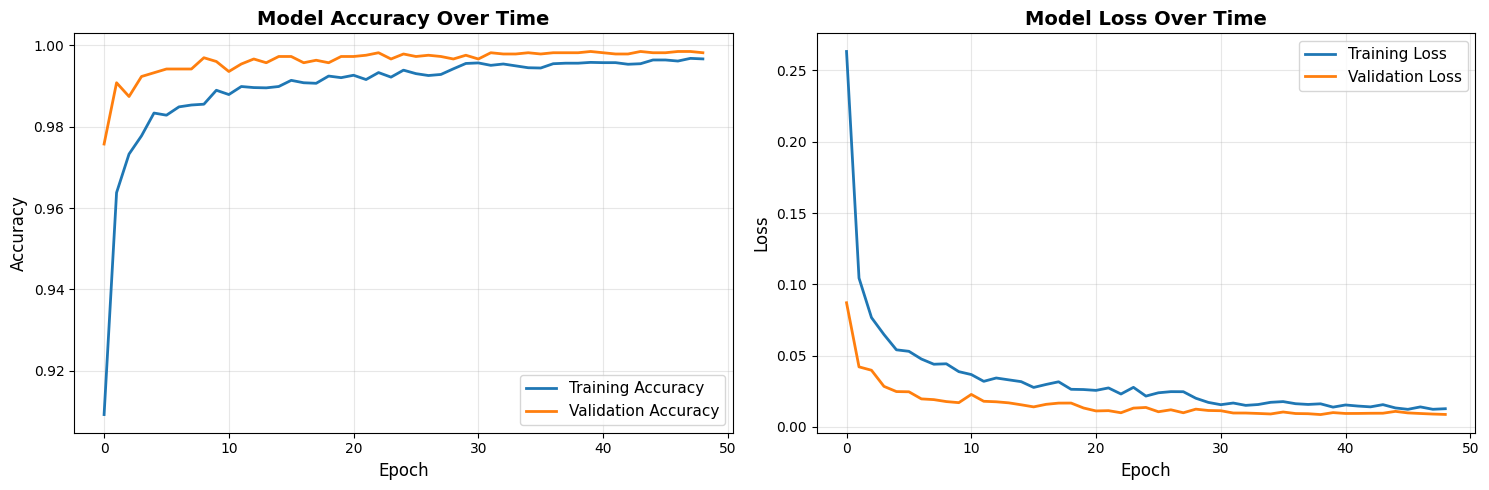

In [ ]:
# Visualize Training History
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HAR_Project/training_history.png', dpi=300, bbox_inches='tight')
print("✓ Training history plot saved!")
plt.show()

In [ ]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
plt.title('Confusion Matrix - Activity Recognition', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HAR_Project/confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved!")
plt.show()

# Per-class accuracy
print("\n📊 Per-Class Accuracy:")
for idx, activity in enumerate(ACTIVITIES):
    class_correct = cm[idx, idx]
    class_total = cm[idx].sum()
    class_acc = (class_correct / class_total) * 100 if class_total > 0 else 0
    print(f" {activity:10s}: {class_acc:5.1f}% ({class_correct}/{class_total})")

NameError: name 'confusion_matrix' is not defined

ENHANCED CONFUSION MATRIX ANALYSIS

✓ Enhanced confusion matrix saved!


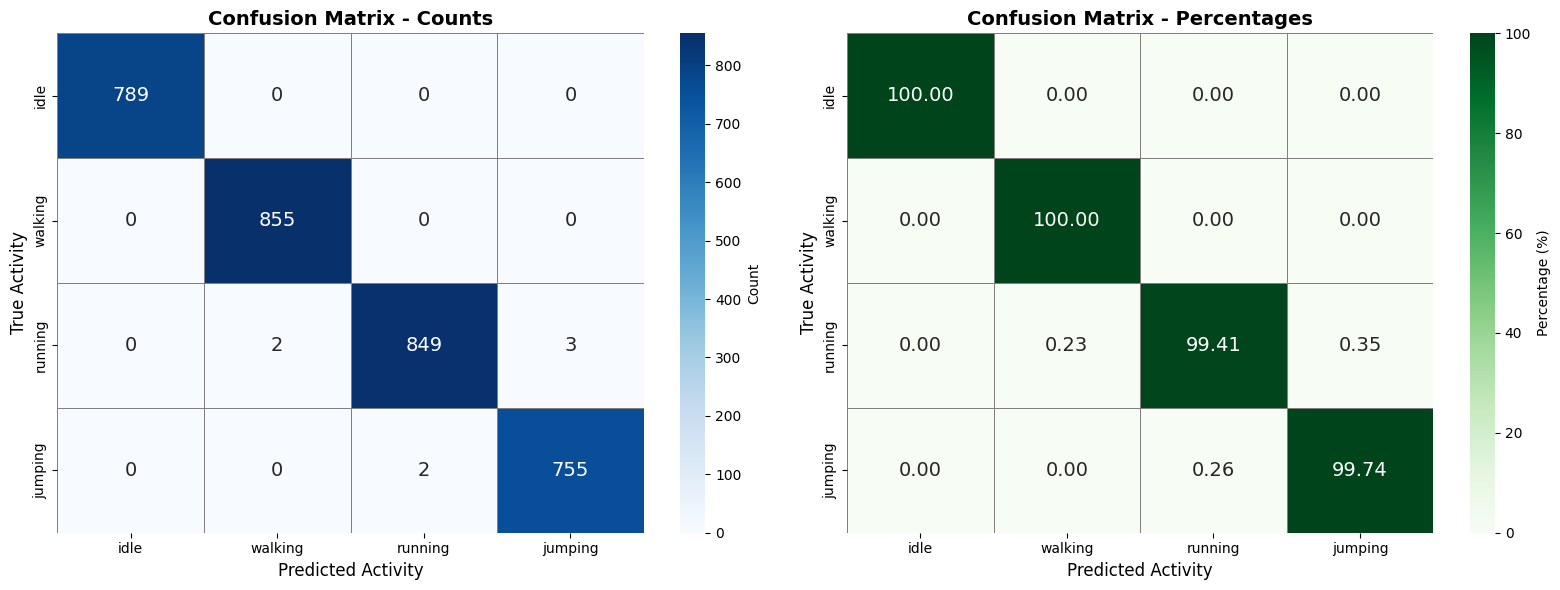


DETAILED MISCLASSIFICATION ANALYSIS

RUNNING → WALKING
  Count: 2 samples
  Rate: 0.23% of all running samples

RUNNING → JUMPING
  Count: 3 samples
  Rate: 0.35% of all running samples
  Reason: Both involve high-intensity vertical movements

JUMPING → RUNNING
  Count: 2 samples
  Rate: 0.26% of all jumping samples

Total Misclassifications: 7 (0.22%)


In [ ]:
print("=" * 60)
print("ENHANCED CONFUSION MATRIX ANALYSIS")
print("=" * 60)

# Create confusion matrix with percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Counts (your existing one, but enhanced)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14},
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Confusion Matrix - Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Activity', fontsize=12)
axes[0].set_xlabel('Predicted Activity', fontsize=12)

# Plot 2: Percentages (NEW - more insightful!)
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            cbar_kws={'label': 'Percentage (%)'}, annot_kws={'size': 14},
            ax=axes[1], linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix - Percentages', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Activity', fontsize=12)
axes[1].set_xlabel('Predicted Activity', fontsize=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HAR_Project/confusion_matrix_enhanced.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Enhanced confusion matrix saved!")
plt.show()

# Print detailed misclassification analysis
print("\n" + "=" * 60)
print("DETAILED MISCLASSIFICATION ANALYSIS")
print("=" * 60)

total_errors = 0
for i, true_activity in enumerate(ACTIVITIES):
    for j, pred_activity in enumerate(ACTIVITIES):
        if i != j and cm[i, j] > 0:
            total_errors += cm[i, j]
            error_rate = cm_percent[i, j]
            print(f"\n{true_activity.upper()} → {pred_activity.upper()}")
            print(f"  Count: {cm[i, j]} samples")
            print(f"  Rate: {error_rate:.2f}% of all {true_activity} samples")

            # Provide interpretation
            if 'running' in true_activity and 'jumping' in pred_activity:
                print(f"  Reason: Both involve high-intensity vertical movements")
            elif 'walking' in true_activity and 'running' in pred_activity:
                print(f"  Reason: Fast walking similar to slow running")

if total_errors == 0:
    print("\n✓ PERFECT CLASSIFICATION - No misclassifications detected!")
else:
    print(f"\nTotal Misclassifications: {total_errors} ({(total_errors/len(y_test)*100):.2f}%)")

In [ ]:
#Save Keras Model
# Save full Keras model
model_path = '/content/drive/MyDrive/HAR_Project/activity_recognition_model.h5'
model.save(model_path)
print(f"✓ Keras model saved: {model_path}")

# Get model size
import os
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f" Model size: {model_size_mb:.2f} MB")


✓ Keras model saved: /content/drive/MyDrive/HAR_Project/activity_recognition_model.h5
 Model size: 0.55 MB


In [ ]:
#Convert to TensorFlow Lite (TinyML)
print("=" * 60)
print("CONVERTING TO TFLITE (TinyML)")
print("=" * 60)

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimization for microcontrollers
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()

# Save TFLite model
tflite_path = '/content/drive/MyDrive/HAR_Project/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tflite_size_kb = len(tflite_model) / 1024

print(f"\n✓ TFLite model saved: {tflite_path}")
print(f" Model size: {tflite_size_kb:.2f} KB")
print(f" Compression: {(1 - tflite_size_kb/(model_size_mb*1024)) * 100:.1f}%")


print(f" Arduino Nano 33 BLE has 1MB flash - this uses only {tflite_size_kb:.1f} KB")

CONVERTING TO TFLITE (TinyML)
Saved artifact at '/tmp/tmpcihmy1se'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139242751818064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139245321474640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139242751818640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139242751818448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139242751817680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139242751819216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139242664903120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139242664903888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139242664903696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139242664904464: TensorSpec(shape=(), dtype=tf.resource, nam

In [ ]:
# Test TFLite Model
print("=" * 60)
print("TESTING TFLITE MODEL")
print("=" * 60)

# Load TFLite model
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\n📋 TFLite Model Details:")
print(f" Input shape: {input_details[0]['shape']}")
print(f" Input type: {input_details[0]['dtype']}")
print(f" Output shape: {output_details[0]['shape']}")
print(f" Output type: {output_details[0]['dtype']}")

# Test with a few samples
print("\n🧪 Testing TFLite predictions:")
num_test_samples = 10
test_indices = np.random.choice(len(X_test), num_test_samples, replace=False)

correct = 0
for idx in test_indices:
    # Prepare input
    test_input = X_test[idx:idx+1].astype(np.float32)

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], test_input)
    interpreter.invoke()

    # Get output
    output = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = np.argmax(output[0])
    true_class = y_test[idx]

    is_correct = predicted_class == true_class
    if is_correct:
        correct += 1

    print(f" Sample {idx}: True={ACTIVITIES[true_class]:8s} | "
          f"Pred={ACTIVITIES[predicted_class]:8s} | "
          f"Conf={output[0][predicted_class]*100:5.1f}% | "
          f"{'✓' if is_correct else '✗'}")

tflite_accuracy = (correct / num_test_samples) * 100
print(f"\n✓ TFLite test accuracy: {tflite_accuracy:.1f}% ({correct}/{num_test_samples})")

TESTING TFLITE MODEL

📋 TFLite Model Details:
 Input shape: [ 1 80  3]
 Input type: <class 'numpy.float32'>
 Output shape: [1 4]
 Output type: <class 'numpy.float32'>

🧪 Testing TFLite predictions:
 Sample 520: True=idle     | Pred=idle     | Conf=100.0% | ✓
 Sample 2262: True=idle     | Pred=idle     | Conf=100.0% | ✓
 Sample 17: True=walking  | Pred=walking  | Conf=100.0% | ✓
 Sample 2904: True=running  | Pred=running  | Conf=100.0% | ✓
 Sample 1945: True=walking  | Pred=walking  | Conf= 99.9% | ✓
 Sample 2162: True=idle     | Pred=idle     | Conf=100.0% | ✓
 Sample 804: True=idle     | Pred=idle     | Conf=100.0% | ✓
 Sample 710: True=jumping  | Pred=jumping  | Conf=100.0% | ✓
 Sample 2244: True=running  | Pred=running  | Conf=100.0% | ✓
 Sample 1545: True=idle     | Pred=idle     | Conf=100.0% | ✓

✓ TFLite test accuracy: 100.0% (10/10)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


PREDICTION CONFIDENCE ANALYSIS

📊 Overall Confidence Statistics:
  Mean Confidence: 99.84%
  Median Confidence: 100.00%
  Min Confidence: 55.98%
  Max Confidence: 100.00%
  Std Deviation: 1.77%

  Predictions >90% confidence: 3242/3255 (99.6%)
  Predictions >95% confidence: 3239/3255 (99.5%)
  Predictions >99% confidence: 3214/3255 (98.7%)

✓ Confidence distribution visualization saved!


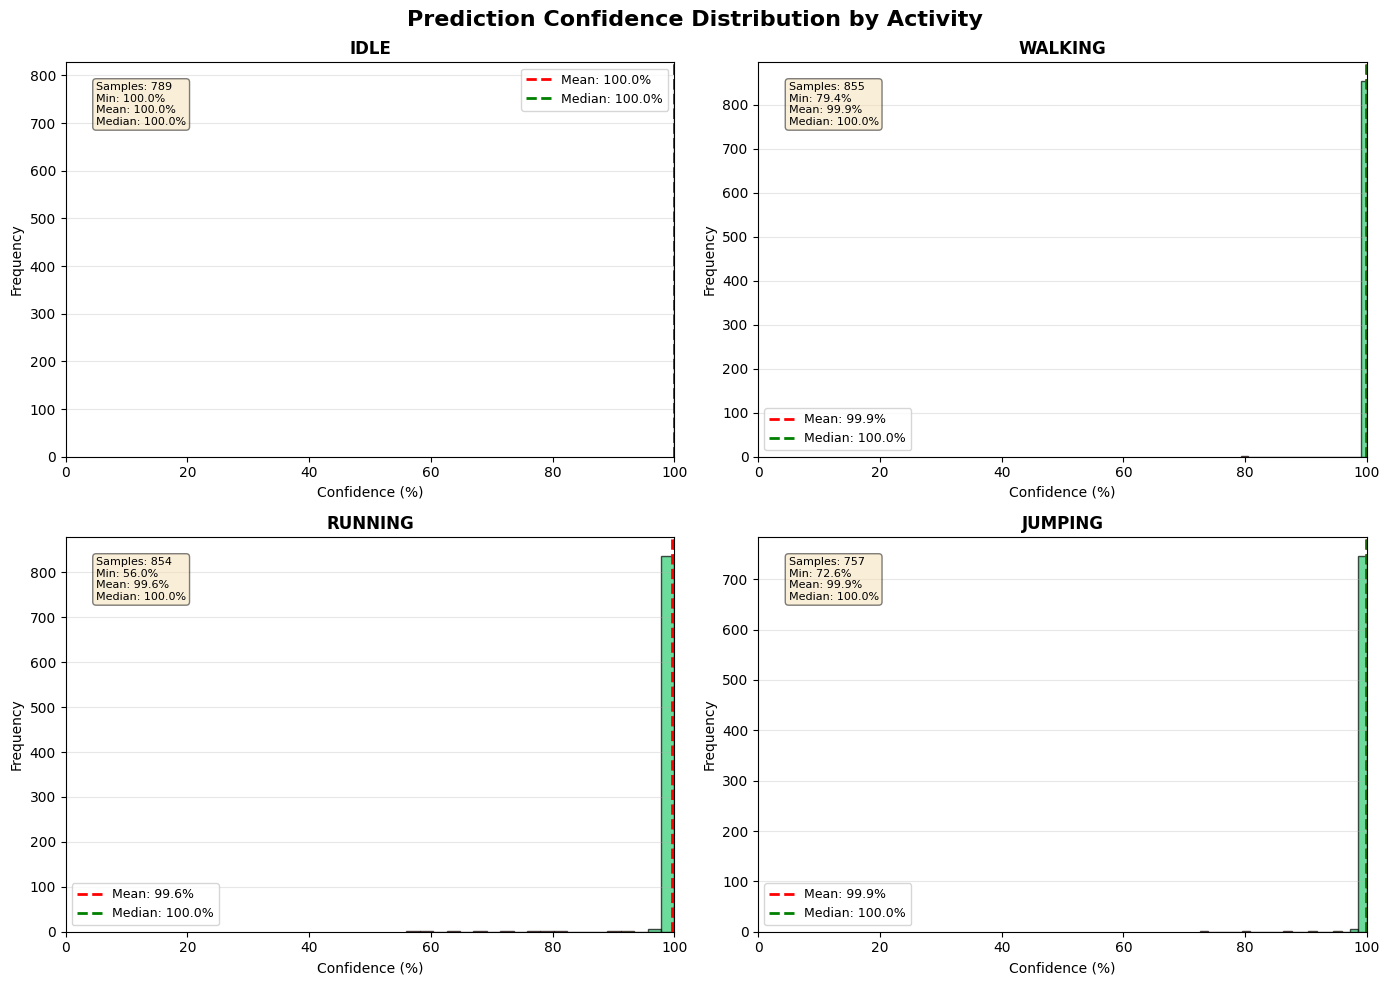


PER-ACTIVITY CONFIDENCE BREAKDOWN

IDLE:
  Mean: 100.00%
  Median: 100.00%
  Min: 100.00%
  Max: 100.00%
  High Confidence (>95%): 789/789 (100.0%)

WALKING:
  Mean: 99.90%
  Median: 99.95%
  Min: 79.39%
  Max: 100.00%
  High Confidence (>95%): 854/855 (99.9%)

RUNNING:
  Mean: 99.61%
  Median: 100.00%
  Min: 55.98%
  Max: 100.00%
  High Confidence (>95%): 843/854 (98.7%)

JUMPING:
  Mean: 99.87%
  Median: 100.00%
  Min: 72.57%
  Max: 100.00%
  High Confidence (>95%): 753/757 (99.5%)


In [ ]:
print("=" * 60)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 60)

# Get all predictions with probabilities
y_pred_proba = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_proba, axis=1)

# Extract confidence scores (max probability for each prediction)
confidences = np.max(y_pred_proba, axis=1) * 100

# Overall confidence statistics
print("\n📊 Overall Confidence Statistics:")
print(f"  Mean Confidence: {np.mean(confidences):.2f}%")
print(f"  Median Confidence: {np.median(confidences):.2f}%")
print(f"  Min Confidence: {np.min(confidences):.2f}%")
print(f"  Max Confidence: {np.max(confidences):.2f}%")
print(f"  Std Deviation: {np.std(confidences):.2f}%")

# Count high confidence predictions
high_conf_90 = np.sum(confidences > 90)
high_conf_95 = np.sum(confidences > 95)
high_conf_99 = np.sum(confidences > 99)

print(f"\n  Predictions >90% confidence: {high_conf_90}/{len(confidences)} ({high_conf_90/len(confidences)*100:.1f}%)")
print(f"  Predictions >95% confidence: {high_conf_95}/{len(confidences)} ({high_conf_95/len(confidences)*100:.1f}%)")
print(f"  Predictions >99% confidence: {high_conf_99}/{len(confidences)} ({high_conf_99/len(confidences)*100:.1f}%)")

# Visualize confidence distribution per activity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Prediction Confidence Distribution by Activity', fontsize=16, fontweight='bold')
axes = axes.ravel()

for idx, activity in enumerate(ACTIVITIES):
    ax = axes[idx]

    # Get confidences for this activity
    activity_mask = (y_test == idx)
    activity_confidences = confidences[activity_mask]

    # Create histogram
    n, bins, patches = ax.hist(activity_confidences, bins=20, color='skyblue',
                               edgecolor='black', alpha=0.7)

    # Color bars based on confidence level
    for i, patch in enumerate(patches):
        if bins[i] >= 95:
            patch.set_facecolor('#2ecc71')  # Green for high confidence
        elif bins[i] >= 90:
            patch.set_facecolor('#f39c12')  # Orange for medium
        else:
            patch.set_facecolor('#e74c3c')  # Red for low

    # Statistics
    mean_conf = np.mean(activity_confidences)
    median_conf = np.median(activity_confidences)
    min_conf = np.min(activity_confidences)

    # Add vertical lines for mean/median
    ax.axvline(mean_conf, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_conf:.1f}%')
    ax.axvline(median_conf, color='green', linestyle='--', linewidth=2,
               label=f'Median: {median_conf:.1f}%')

    ax.set_title(f'{activity.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Confidence (%)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(0, 100)

    # Add stats text box
    textstr = f'Samples: {len(activity_confidences)}\nMin: {min_conf:.1f}%\nMean: {mean_conf:.1f}%\nMedian: {median_conf:.1f}%'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HAR_Project/confidence_distribution.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Confidence distribution visualization saved!")
plt.show()

# Per-activity confidence breakdown
print("\n" + "=" * 60)
print("PER-ACTIVITY CONFIDENCE BREAKDOWN")
print("=" * 60)

for idx, activity in enumerate(ACTIVITIES):
    activity_mask = (y_test == idx)
    activity_confidences = confidences[activity_mask]

    print(f"\n{activity.upper()}:")
    print(f"  Mean: {np.mean(activity_confidences):.2f}%")
    print(f"  Median: {np.median(activity_confidences):.2f}%")
    print(f"  Min: {np.min(activity_confidences):.2f}%")
    print(f"  Max: {np.max(activity_confidences):.2f}%")

    # High confidence count
    high_conf = np.sum(activity_confidences > 95)
    print(f"  High Confidence (>95%): {high_conf}/{len(activity_confidences)} ({high_conf/len(activity_confidences)*100:.1f}%)")

In [ ]:
#Generate Project Summary
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

summary = f"""
📊 HUMAN ACTIVITY RECOGNITION WITH TINYML
{'=' * 60}

📁 Dataset Information:
   • Total samples: {len(X):,}
   • Window size: {WINDOW_SIZE} timesteps
   • Features per timestep: 3 (X, Y, Z acceleration)
   • Activities: {', '.join(ACTIVITIES)}

🎯 Model Performance:
   • Test Accuracy: {test_acc * 100:.2f}%
   • Test Loss: {test_loss:.4f}
   • Model Parameters: {total_params:,}

💾 Model Files:
   • Keras Model: activity_recognition_model.h5 ({model_size_mb:.2f} MB)
   • TFLite Model: model.tflite ({tflite_size_kb:.2f} KB)
   • Size Reduction: {(1 - tflite_size_kb/(model_size_mb*1024)) * 100:.1f}%

✅ Generated Files (saved to Google Drive):
   1. activity_recognition_model.h5 - Full Keras model
   2. model.tflite - TinyML optimized model
   3. training_history.png - Training visualization
   4. confusion_matrix.png - Performance visualization
   5. sample_data_visualization.png - Data samples

🚀 Deployment Ready:
   • Model size ({tflite_size_kb:.2f} KB) is suitable for microcontrollers
   • Compatible with Arduino, ESP32, Raspberry Pi Pico
   • Can run real-time inference on edge devices

{'=' * 60}
"""

print(summary)

# Save summary
with open('/content/drive/MyDrive/HAR_Project/project_summary.txt', 'w') as f:
    f.write(summary)

print("✓ Project summary saved to Google Drive!")
print("\n🎉 PROJECT COMPLETE! All files saved to:")
print(" Google Drive → HAR_Project/")


PROJECT SUMMARY

📊 HUMAN ACTIVITY RECOGNITION WITH TINYML

📁 Dataset Information:
   • Total samples: 21,694
   • Window size: 80 timesteps
   • Features per timestep: 3 (X, Y, Z acceleration)
   • Activities: idle, walking, running, jumping

🎯 Model Performance:
   • Test Accuracy: 99.82%
   • Test Loss: 0.0096
   • Model Parameters: 43,204

💾 Model Files:
   • Keras Model: activity_recognition_model.h5 (0.55 MB)
   • TFLite Model: model.tflite (51.94 KB)
   • Size Reduction: 90.8%

✅ Generated Files (saved to Google Drive):
   1. activity_recognition_model.h5 - Full Keras model
   2. model.tflite - TinyML optimized model
   3. training_history.png - Training visualization
   4. confusion_matrix.png - Performance visualization
   5. sample_data_visualization.png - Data samples

🚀 Deployment Ready:
   • Model size (51.94 KB) is suitable for microcontrollers
   • Compatible with Arduino, ESP32, Raspberry Pi Pico
   • Can run real-time inference on edge devices


✓ Project summary saved

### **Single File Testing Function**

In [ ]:
print("=" * 60)
print("INTERACTIVE MODEL TESTING")
print("=" * 60)

def test_single_csv(csv_path):
    """
    Test the model on a single CSV file
    """
    print(f"\n🔍 Testing: {csv_path}")

    # Load CSV
    try:
        data = load_csv_file(csv_path)

        if data is None or len(data) < WINDOW_SIZE:
            print(f"❌ Error: Not enough data in file")
            return

        print(f"✓ Loaded {len(data)} samples")

        # Create windows
        windows = create_windows(data, WINDOW_SIZE, STEP_SIZE)
        print(f"✓ Created {len(windows)} windows")

        # Predict with TFLite model
        predictions = []
        confidences = []

        for window in windows:
            window_input = np.expand_dims(window, axis=0).astype(np.float32)

            # Run inference
            interpreter.set_tensor(input_details[0]['index'], window_input)
            interpreter.invoke()
            output = interpreter.get_tensor(output_details[0]['index'])

            predicted_class = np.argmax(output[0])
            confidence = output[0][predicted_class]

            predictions.append(predicted_class)
            confidences.append(confidence)

        # Get most common prediction
        from collections import Counter
        prediction_counts = Counter(predictions)
        final_prediction = prediction_counts.most_common(1)[0][0]

        # Calculate average confidence for the final prediction
        avg_confidence = np.mean([conf for pred, conf in zip(predictions, confidences)
                                 if pred == final_prediction])

        # Display results
        print("\n" + "=" * 60)
        print("PREDICTION RESULT")
        print("=" * 60)
        print(f"\n🎯 Predicted Activity: {ACTIVITIES[final_prediction].upper()}")
        print(f"📊 Confidence: {avg_confidence * 100:.2f}%")
        print(f"📈 Based on {len(windows)} windows")

        # Show distribution of predictions
        print("\nPrediction distribution across windows:")
        for activity_idx, activity in enumerate(ACTIVITIES):
            count = predictions.count(activity_idx)
            percentage = (count / len(predictions)) * 100
            bar = "█" * int(percentage / 5)
            print(f"  {activity:10s}: {bar} {count}/{len(predictions)} ({percentage:.1f}%)")

        # Visualize
        visualize_test_result(data, final_prediction, avg_confidence, predictions, confidences)

        return final_prediction, avg_confidence

    except Exception as e:
        print(f"❌ Error testing file: {e}")
        return None, None

def visualize_test_result(data, predicted_class, avg_confidence, all_predictions, all_confidences):
    """
    Visualize the test results
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    # Plot 1: Raw sensor data
    ax1 = axes[0]
    time = np.arange(len(data)) / 100  # Assuming ~100Hz
    ax1.plot(time, data[:, 0], label='X-axis', linewidth=1.5, alpha=0.8)
    ax1.plot(time, data[:, 1], label='Y-axis', linewidth=1.5, alpha=0.8)
    ax1.plot(time, data[:, 2], label='Z-axis', linewidth=1.5, alpha=0.8)
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel('Acceleration (m/s²)', fontsize=12)
    ax1.set_title('Sensor Data (3-axis Accelerometer)', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Predictions over time
    ax2 = axes[1]
    window_indices = range(len(all_predictions))
    colors = [plt.cm.Set3(p) for p in all_predictions]
    ax2.scatter(window_indices, all_predictions, c=colors, s=100, alpha=0.7, edgecolors='black')
    ax2.set_xlabel('Window Index', fontsize=12)
    ax2.set_ylabel('Predicted Activity', fontsize=12)
    ax2.set_yticks(range(len(ACTIVITIES)))
    ax2.set_yticklabels(ACTIVITIES)
    ax2.set_title('Predictions Across Windows', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    # Plot 3: Final prediction confidence
    ax3 = axes[2]
    colors = ['#ff6b6b' if i != predicted_class else '#51cf66' for i in range(len(ACTIVITIES))]
    bars = ax3.bar(ACTIVITIES, [0] * len(ACTIVITIES), color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    bars[predicted_class].set_height(avg_confidence * 100)

    ax3.set_ylabel('Confidence (%)', fontsize=12)
    ax3.set_title(f'Final Prediction: {ACTIVITIES[predicted_class].upper()} ({avg_confidence*100:.1f}% confidence)',
                  fontsize=14, fontweight='bold', color='green')
    ax3.set_ylim(0, 100)
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value label
    height = bars[predicted_class].get_height()
    ax3.text(bars[predicted_class].get_x() + bars[predicted_class].get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/HAR_Project/test_prediction.png', dpi=300, bbox_inches='tight')
    print("\n✓ Visualization saved as 'test_prediction.png'")
    plt.show()

print("✓ Testing functions defined!")

INTERACTIVE MODEL TESTING
✓ Testing functions defined!


##         **Batch Test Multiple Files**

In [ ]:
print("=" * 60)
print("BATCH TESTING - Test Multiple Files at Once")
print("=" * 60)

def batch_test_activity(activity_name, num_files=5):
    """
    Test multiple files from one activity
    """
    activity_path = f'/content/drive/MyDrive/HAR_Project/sensor_data/{activity_name}'

    csv_files = sorted([f for f in os.listdir(activity_path) if f.endswith('.csv')])[:num_files]

    print(f"\n📁 Testing {activity_name.upper()}")
    print(f"   Files to test: {len(csv_files)}")
    print("-" * 60)

    correct = 0
    total = 0

    activity_idx = ACTIVITIES.index(activity_name)

    for csv_file in csv_files:
        file_path = os.path.join(activity_path, csv_file)

        # Load and predict
        try:
            data = load_csv_file(file_path)
            if data is None or len(data) < WINDOW_SIZE:
                continue

            windows = create_windows(data, WINDOW_SIZE, STEP_SIZE)

            # Get majority prediction
            predictions = []
            for window in windows:
                window_input = np.expand_dims(window, axis=0).astype(np.float32)
                interpreter.set_tensor(input_details[0]['index'], window_input)
                interpreter.invoke()
                output = interpreter.get_tensor(output_details[0]['index'])
                predictions.append(np.argmax(output[0]))

            from collections import Counter
            final_pred = Counter(predictions).most_common(1)[0][0]

            total += 1
            if final_pred == activity_idx:
                correct += 1
                status = "✓"
            else:
                status = "✗"

            print(f"  {status} {csv_file:25s} | Predicted: {ACTIVITIES[final_pred]:10s}")

        except Exception as e:
            print(f"  ✗ {csv_file:25s} | Error: {str(e)[:30]}")

    if total > 0:
        accuracy = (correct / total) * 100
        print(f"\n  Accuracy: {correct}/{total} ({accuracy:.1f}%)")

    return correct, total

# Test all activities
print("\n" + "=" * 60)
print("TESTING ALL ACTIVITIES")
print("=" * 60)

total_correct = 0
total_tested = 0

for activity in ACTIVITIES:
    correct, tested = batch_test_activity(activity, num_files=5)
    total_correct += correct
    total_tested += tested

print("\n" + "=" * 60)
print("OVERALL BATCH TEST RESULTS")
print("=" * 60)

if total_tested > 0:
    overall_accuracy = (total_correct / total_tested) * 100
    print(f"\n✓ Total Accuracy: {total_correct}/{total_tested} ({overall_accuracy:.1f}%)")
else:
    print("\n❌ No files were tested")

BATCH TESTING - Test Multiple Files at Once

TESTING ALL ACTIVITIES

📁 Testing IDLE
   Files to test: 5
------------------------------------------------------------
  ✓ Raw Data_1.csv            | Predicted: idle      
  ✓ Raw Data_10.csv           | Predicted: idle      
  ✓ Raw Data_11.csv           | Predicted: idle      
  ✓ Raw Data_12.csv           | Predicted: idle      
  ✓ Raw Data_13.csv           | Predicted: idle      

  Accuracy: 5/5 (100.0%)

📁 Testing WALKING
   Files to test: 5
------------------------------------------------------------
  ✓ Raw Data_1 (1).csv        | Predicted: walking   
  ✓ Raw Data_10 (1).csv       | Predicted: walking   
  ✓ Raw Data_11 (1).csv       | Predicted: walking   
  ✓ Raw Data_12 (1).csv       | Predicted: walking   
  ✓ Raw Data_13 (1).csv       | Predicted: walking   

  Accuracy: 5/5 (100.0%)

📁 Testing RUNNING
   Files to test: 5
------------------------------------------------------------
  ✓ running_1.csv             | Predicted: 

### **Random Sample Testing**

TEST WITH NEW DATA (Upload CSV)

📤 Click 'Choose Files' to upload a CSV file for testing
   (This should be NEW data not used in training)



Saving jumping_27.csv to jumping_27 (1).csv

✓ File uploaded: jumping_27 (1).csv


🔍 Testing: jumping_27 (1).csv
✓ Loaded 8149 samples
✓ Created 202 windows

PREDICTION RESULT

🎯 Predicted Activity: JUMPING
📊 Confidence: 99.99%
📈 Based on 202 windows

Prediction distribution across windows:
  idle      :  0/202 (0.0%)
  walking   :  0/202 (0.0%)
  running   :  0/202 (0.0%)
  jumping   : ████████████████████ 202/202 (100.0%)

✓ Visualization saved as 'test_prediction.png'


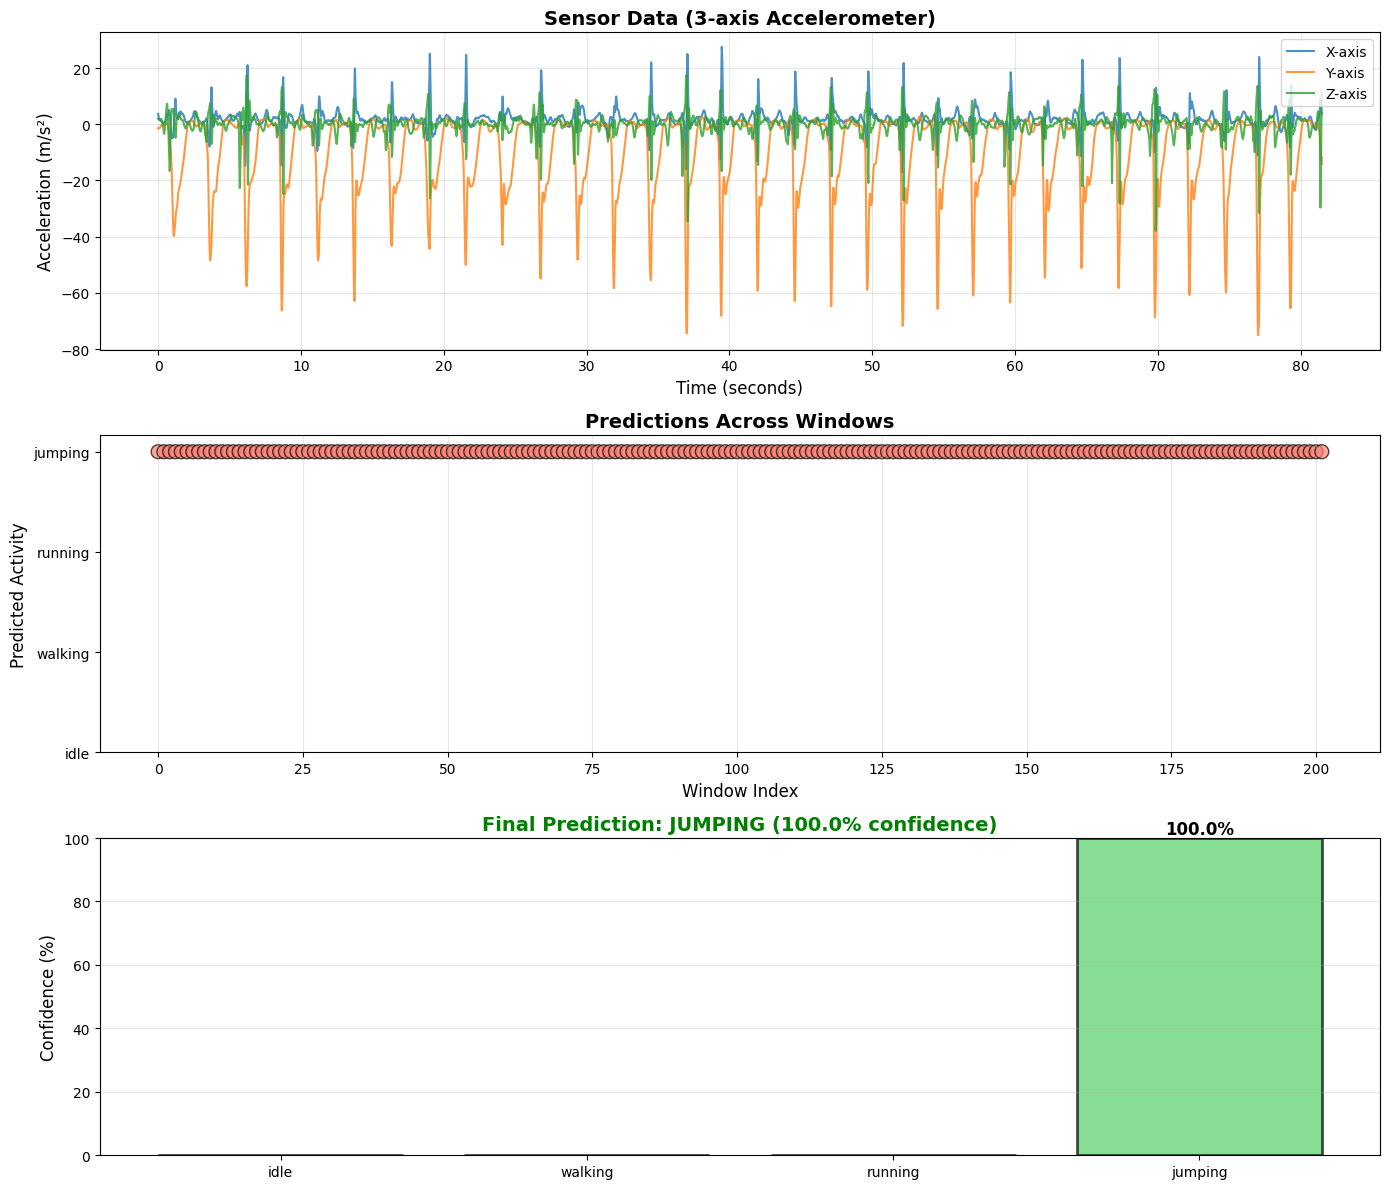

In [ ]:
print("=" * 60)
print("TEST WITH NEW DATA (Upload CSV)")
print("=" * 60)

from google.colab import files

print("\n📤 Click 'Choose Files' to upload a CSV file for testing")
print("   (This should be NEW data not used in training)")
print()

uploaded = files.upload()

if uploaded:
    # Get the uploaded filename
    filename = list(uploaded.keys())[0]
    print(f"\n✓ File uploaded: {filename}")

    # Test it
    print("\n" + "=" * 60)
    test_single_csv(filename)
else:
    print("No file uploaded")


📤 Click 'Choose Files' to upload a CSV file for testing
   (This should be NEW data not used in training)



Saving running_26.csv to running_26 (1).csv

✓ File uploaded: running_26 (1).csv


🔍 Testing: running_26 (1).csv
✓ Loaded 9161 samples
✓ Created 228 windows

PREDICTION RESULT

🎯 Predicted Activity: RUNNING
📊 Confidence: 99.98%
📈 Based on 228 windows

Prediction distribution across windows:
  idle      :  0/228 (0.0%)
  walking   :  0/228 (0.0%)
  running   : ████████████████████ 228/228 (100.0%)
  jumping   :  0/228 (0.0%)

✓ Visualization saved as 'test_prediction.png'


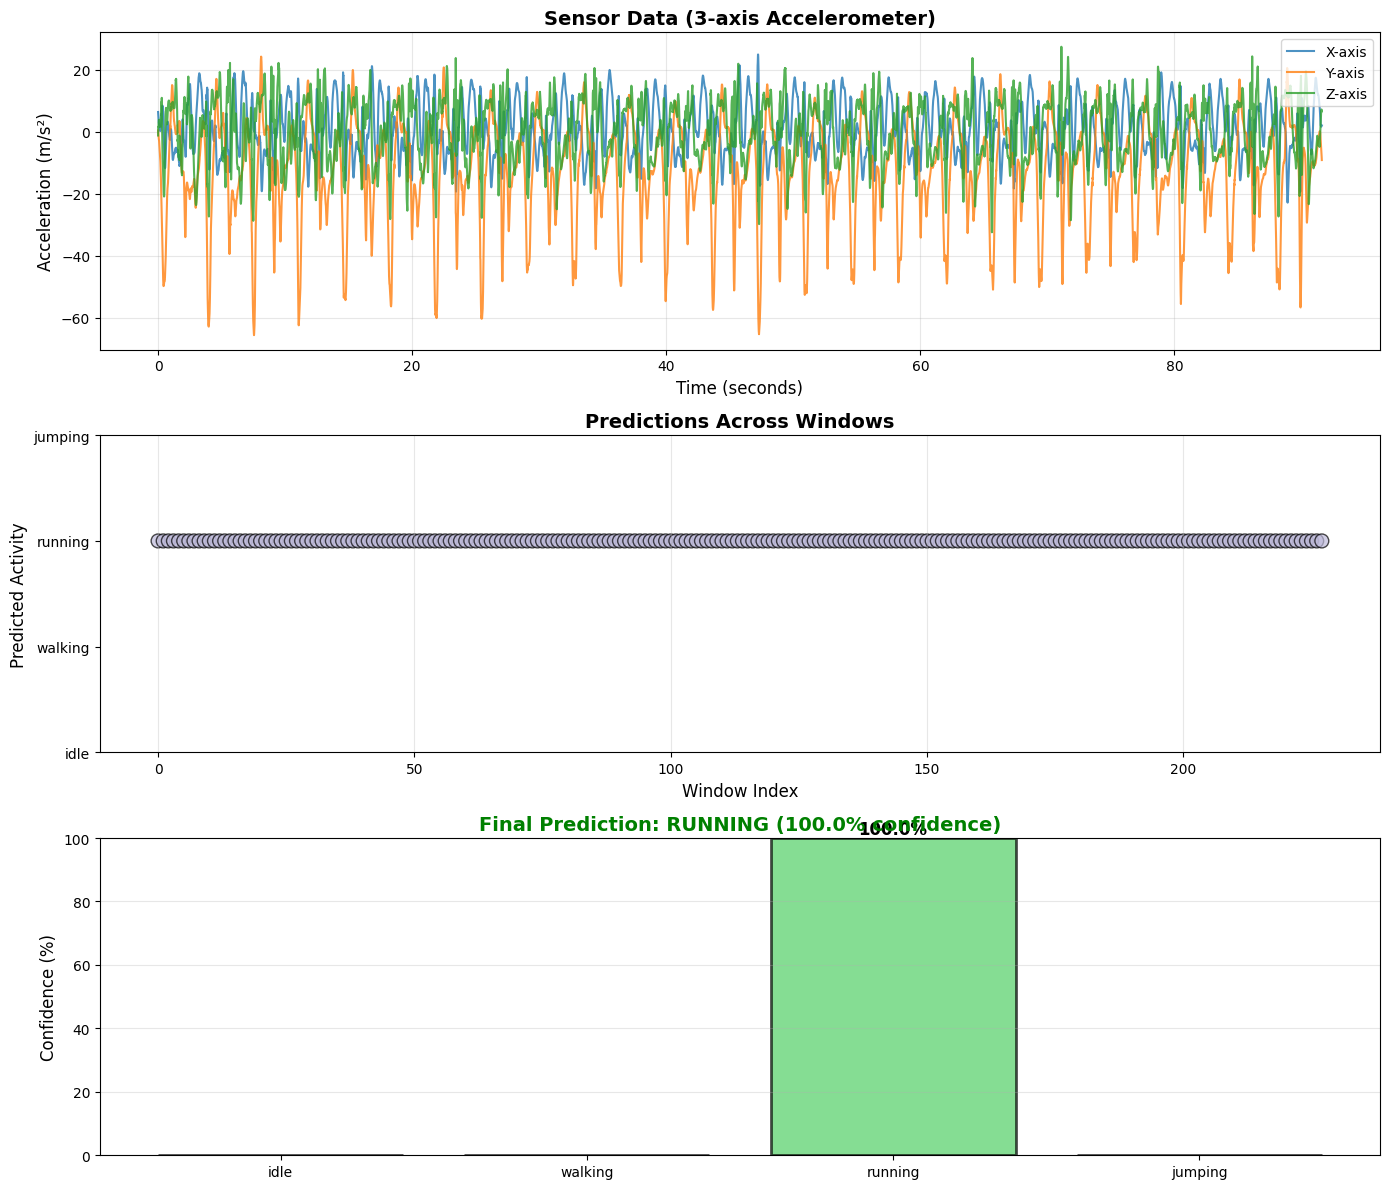

In [ ]:
from google.colab import files

print("\n📤 Click 'Choose Files' to upload a CSV file for testing")
print("   (This should be NEW data not used in training)")
print()

uploaded = files.upload()

if uploaded:
    # Get the uploaded filename
    filename = list(uploaded.keys())[0]
    print(f"\n✓ File uploaded: {filename}")

    # Test it
    print("\n" + "=" * 60)
    test_single_csv(filename)
else:
    print("No file uploaded")


📤 Click 'Choose Files' to upload a CSV file for testing
   (This should be NEW data not used in training)



Saving Raw Data_27.csv to Raw Data_27 (1).csv

✓ File uploaded: Raw Data_27 (1).csv


🔍 Testing: Raw Data_27 (1).csv
✓ Loaded 9165 samples
✓ Created 228 windows

PREDICTION RESULT

🎯 Predicted Activity: WALKING
📊 Confidence: 99.94%
📈 Based on 228 windows

Prediction distribution across windows:
  idle      :  0/228 (0.0%)
  walking   : ████████████████████ 228/228 (100.0%)
  running   :  0/228 (0.0%)
  jumping   :  0/228 (0.0%)

✓ Visualization saved as 'test_prediction.png'


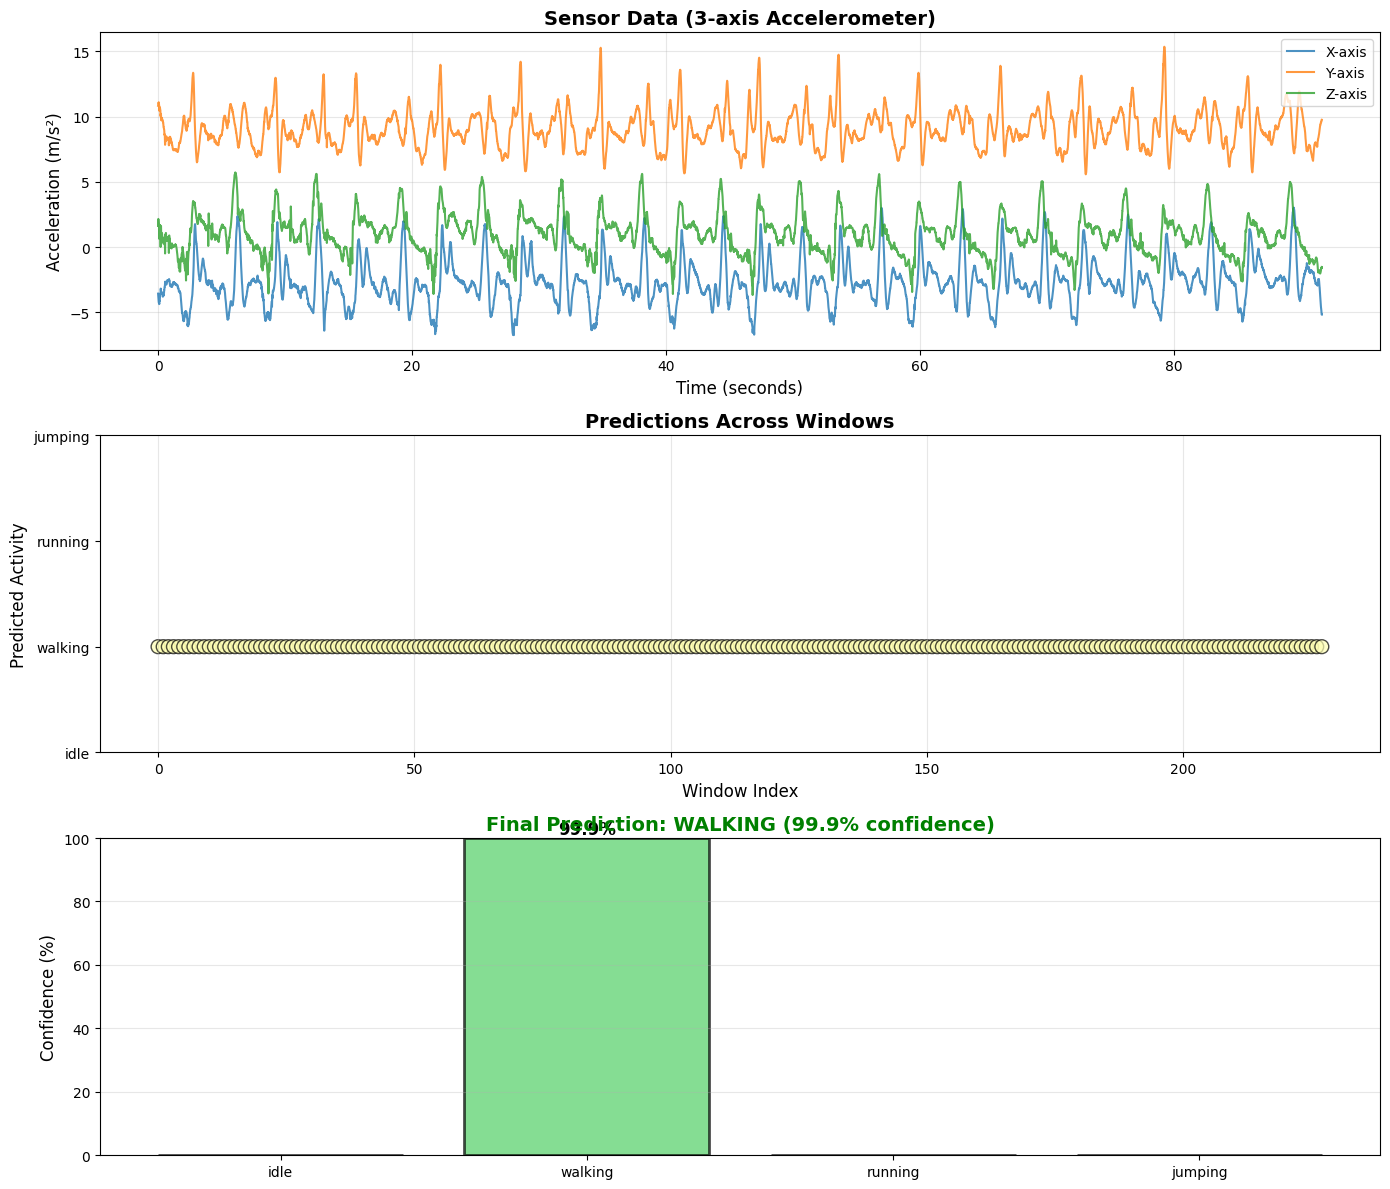

In [ ]:
from google.colab import files

print("\n📤 Click 'Choose Files' to upload a CSV file for testing")
print("   (This should be NEW data not used in training)")
print()

uploaded = files.upload()

if uploaded:
    # Get the uploaded filename
    filename = list(uploaded.keys())[0]
    print(f"\n✓ File uploaded: {filename}")

    # Test it
    print("\n" + "=" * 60)
    test_single_csv(filename)
else:
    print("No file uploaded")


📤 Click 'Choose Files' to upload a CSV file for testing
   (This should be NEW data not used in training)



Saving Raw Data_26.csv to Raw Data_26 (1).csv

✓ File uploaded: Raw Data_26 (1).csv


🔍 Testing: Raw Data_26 (1).csv
✓ Loaded 8153 samples
✓ Created 202 windows

PREDICTION RESULT

🎯 Predicted Activity: IDLE
📊 Confidence: 100.00%
📈 Based on 202 windows

Prediction distribution across windows:
  idle      : ████████████████████ 202/202 (100.0%)
  walking   :  0/202 (0.0%)
  running   :  0/202 (0.0%)
  jumping   :  0/202 (0.0%)

✓ Visualization saved as 'test_prediction.png'


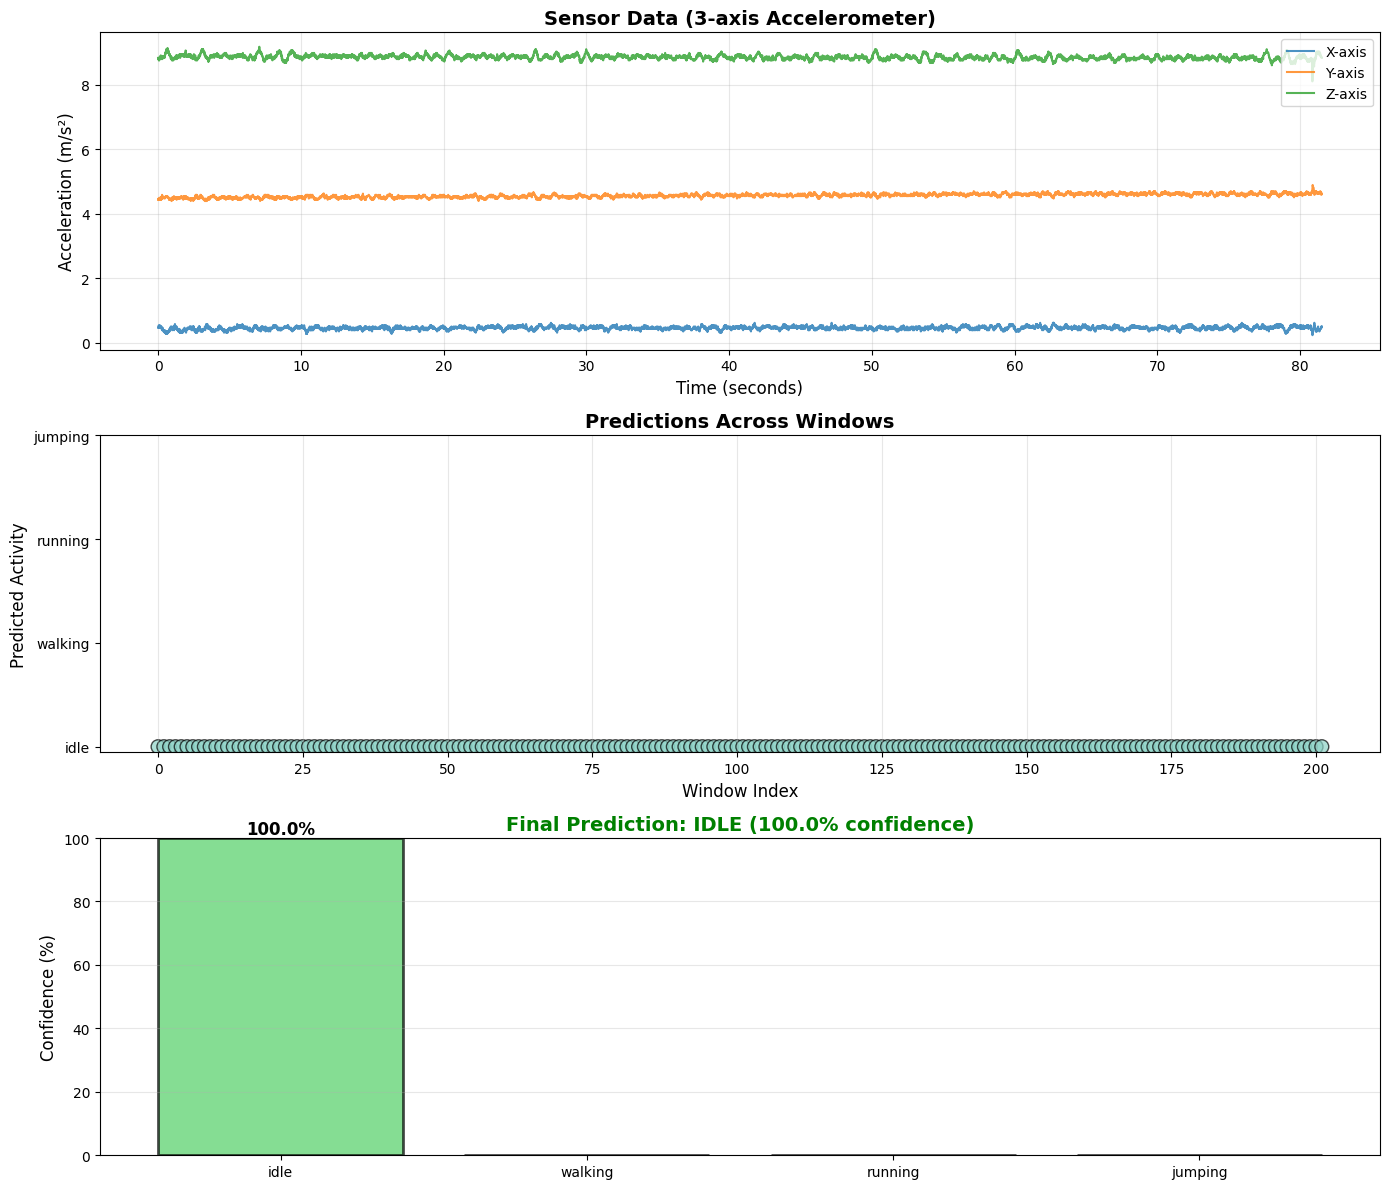

In [ ]:
from google.colab import files

print("\n📤 Click 'Choose Files' to upload a CSV file for testing")
print("   (This should be NEW data not used in training)")
print()

uploaded = files.upload()

if uploaded:
    # Get the uploaded filename
    filename = list(uploaded.keys())[0]
    print(f"\n✓ File uploaded: {filename}")

    # Test it
    print("\n" + "=" * 60)
    test_single_csv(filename)
else:
    print("No file uploaded")